# EDA-05 · Hiệu Quả Tài Chính (Financial Performance)
Four sections: **Revenue & GP Trend** · **Seasonality & Demand** · **Promotion Impact (incl. stackable)** · **Product Pareto 80/20**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

sales   = pd.read_csv('sales.csv',       parse_dates=['Date'])
orders  = pd.read_csv('orders.csv',      parse_dates=['order_date'])
items   = pd.read_csv('order_items.csv', low_memory=False)
prods   = pd.read_csv('products.csv')
promos  = pd.read_csv('promotions.csv')
rets    = pd.read_csv('returns.csv')

# Derived
sales['year']         = sales['Date'].dt.year
sales['month']        = sales['Date'].dt.month
sales['dow']          = sales['Date'].dt.dayofweek      # 0=Mon
sales['GrossProfit']  = sales['Revenue'] - sales['COGS']
sales['GM_pct']       = sales['GrossProfit'] / sales['Revenue'] * 100

items['rev_line']  = items['quantity'] * items['unit_price']
items['cogs_line'] = items['quantity'].astype(float)    # filled after merge
items_prod = items.merge(prods[['product_id','category','segment','price','cogs']],
                         on='product_id', how='left')
items_prod['cogs_line'] = items_prod['quantity'] * items_prod['cogs']
items_prod['gp_line']   = items_prod['rev_line'] - items_prod['cogs_line']

print(f'sales : {sales.shape}  ({sales["Date"].min().date()} → {sales["Date"].max().date()})')
print(f'orders: {orders.shape}')
print(f'items : {items.shape}')
print(f'prods : {prods.shape}')
print(f'rets  : {rets.shape}')


sales : (3833, 8)  (2012-07-04 → 2022-12-31)
orders: (646945, 8)
items : (714669, 9)
prods : (2412, 8)
rets  : (39939, 7)


## Part 1 · Revenue & Gross Profit Trend by Year

In [2]:
annual = sales.groupby('year').agg(
    Revenue     = ('Revenue',     'sum'),
    COGS        = ('COGS',        'sum'),
    GrossProfit = ('GrossProfit', 'sum'),
).reset_index()
annual['GM_pct']   = annual['GrossProfit'] / annual['Revenue'] * 100
annual['rev_yoy']  = annual['Revenue'].pct_change() * 100
annual['gp_yoy']   = annual['GrossProfit'].pct_change() * 100

print(annual[['year','Revenue','COGS','GrossProfit','GM_pct','rev_yoy']].to_string(index=False))


 year      Revenue         COGS  GrossProfit    GM_pct    rev_yoy
 2012 7.414977e+08 5.874619e+08 154035824.21 20.773606        NaN
 2013 1.657169e+09 1.465980e+09 191189314.07 11.537101 123.489474
 2014 1.871846e+09 1.574607e+09 297238425.91 15.879428  12.954407
 2015 1.889934e+09 1.665442e+09 224492009.50 11.878300   0.966316
 2016 2.104641e+09 1.780559e+09 324081284.85 15.398414  11.360549
 2017 1.911164e+09 1.694386e+09 216778531.74 11.342747  -9.192845
 2018 1.850122e+09 1.542176e+09 307946689.94 16.644665  -3.193962
 2019 1.136801e+09 1.005203e+09 131598557.79 11.576213 -38.555341
 2020 1.054512e+09 8.860851e+08 168427061.16 15.972036  -7.238668
 2021 1.043040e+09 9.411301e+08 101909699.47  9.770451  -1.087929
 2022 1.169749e+09 1.020420e+09 149328667.72 12.765874  12.148051


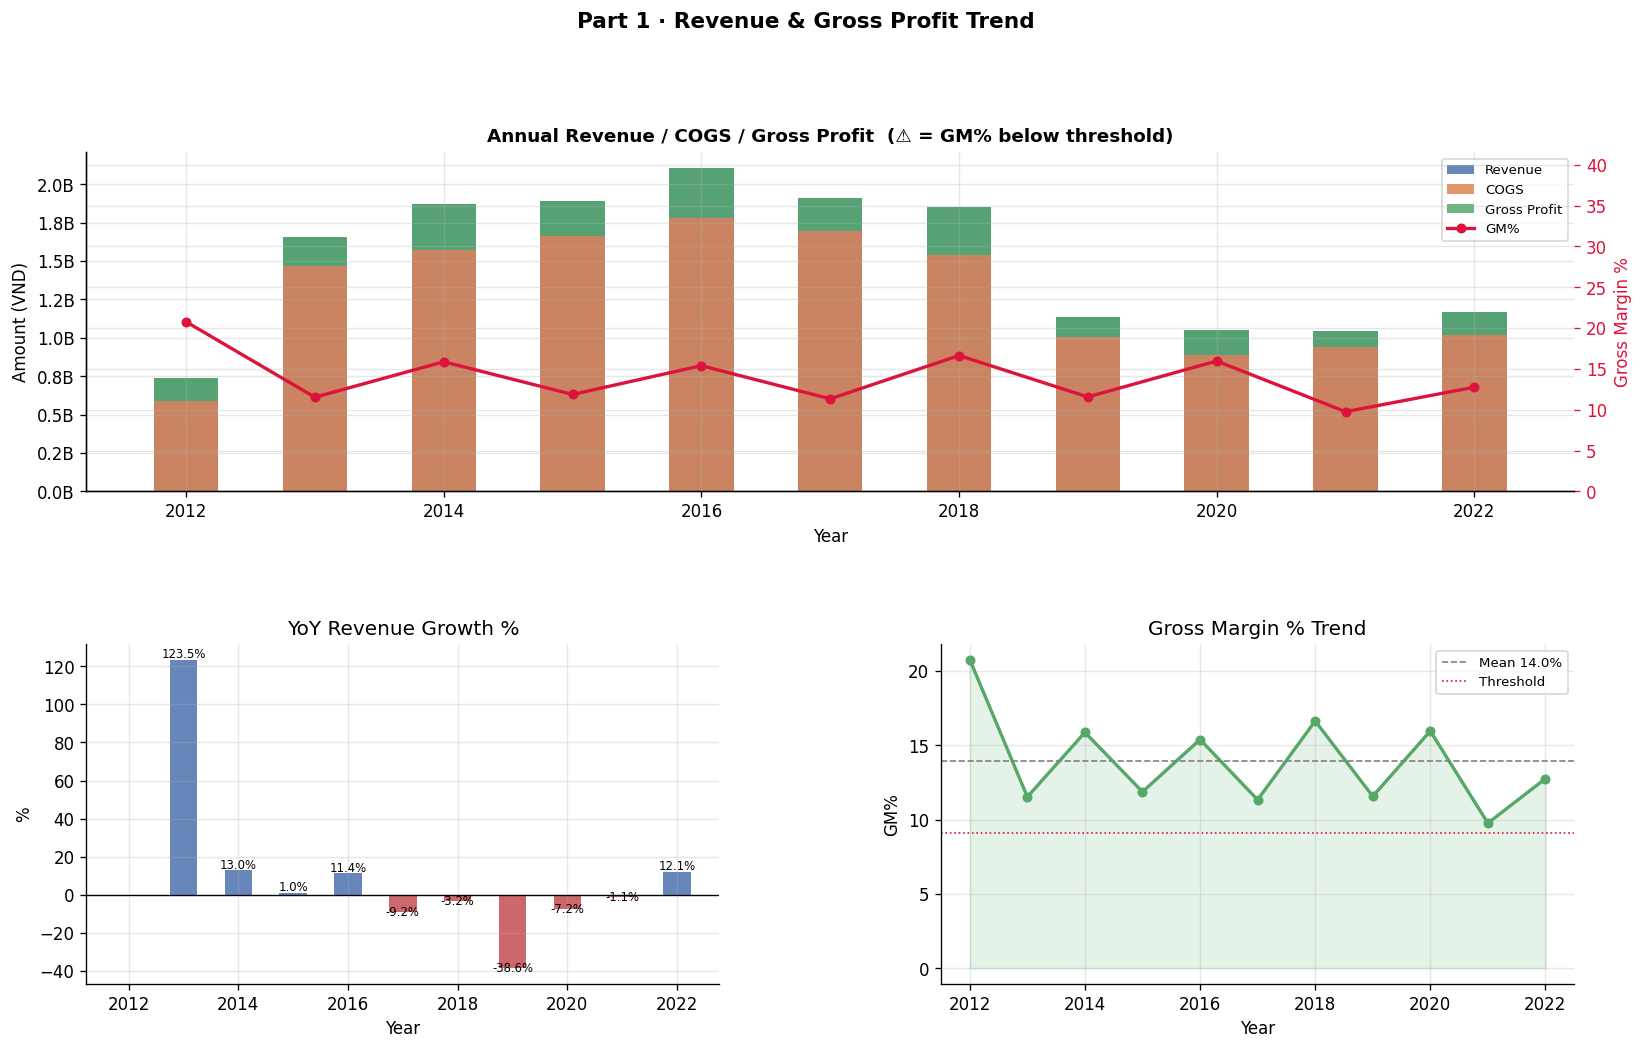

Anomalous GM% years: None
GM% range: 9.8% – 20.8%


In [3]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel A: Stacked bar Revenue & COGS ──────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :])
x   = annual['year']
ax0.bar(x, annual['Revenue'],      label='Revenue',      color='#4C72B0', width=0.5, alpha=0.85)
ax0.bar(x, annual['COGS'],         label='COGS',         color='#DD8452', width=0.5, alpha=0.85)
ax0.bar(x, annual['GrossProfit'],  label='Gross Profit', color='#55A868', width=0.5, alpha=0.85,
        bottom=annual['COGS'])

ax_gm = ax0.twinx()
ax_gm.plot(x, annual['GM_pct'], color='crimson', marker='o', lw=2, ms=5, label='GM%')
ax_gm.set_ylabel('Gross Margin %', color='crimson')
ax_gm.tick_params(axis='y', colors='crimson')
ax_gm.set_ylim(0, annual['GM_pct'].max() * 2)

# Anomaly: flag years where GM% < mean - 1.5*std
gm_mean, gm_std = annual['GM_pct'].mean(), annual['GM_pct'].std()
anomalies = annual[annual['GM_pct'] < gm_mean - 1.5*gm_std]
for _, row in anomalies.iterrows():
    ax0.annotate(f'⚠ Low GM\n{row["GM_pct"]:.1f}%',
                 xy=(row['year'], row['Revenue']*0.5),
                 fontsize=7.5, color='darkred', ha='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', ec='darkred', alpha=0.8))

ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e9:.1f}B'))
ax0.set_title('Annual Revenue / COGS / Gross Profit  (⚠ = GM% below threshold)', fontsize=11, fontweight='bold')
ax0.set_xlabel('Year'); ax0.set_ylabel('Amount (VND)')
lines0, labs0 = ax0.get_legend_handles_labels()
lines1, labs1 = ax_gm.get_legend_handles_labels()
ax0.legend(lines0+lines1, labs0+labs1, loc='upper right', fontsize=8)

# ── Panel B: YoY Revenue Growth ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
colors_yoy = ['#C44E52' if v < 0 else '#4C72B0' for v in annual['rev_yoy'].fillna(0)]
ax1.bar(annual['year'], annual['rev_yoy'].fillna(0), color=colors_yoy, width=0.5, alpha=0.85)
ax1.axhline(0, color='black', lw=0.8)
ax1.set_title('YoY Revenue Growth %'); ax1.set_xlabel('Year'); ax1.set_ylabel('%')
for _, row in annual.dropna(subset=['rev_yoy']).iterrows():
    ax1.text(row['year'], row['rev_yoy'] + (1 if row['rev_yoy'] >= 0 else -2),
             f"{row['rev_yoy']:.1f}%", ha='center', fontsize=7)

# ── Panel C: Gross Margin % Trend ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(annual['year'], annual['GM_pct'], color='#55A868', marker='o', lw=2, ms=5)
ax2.fill_between(annual['year'], annual['GM_pct'], alpha=0.15, color='#55A868')
ax2.axhline(gm_mean, color='grey', lw=1, linestyle='--', label=f'Mean {gm_mean:.1f}%')
ax2.axhline(gm_mean - 1.5*gm_std, color='crimson', lw=1, linestyle=':', label='Threshold')
for _, row in anomalies.iterrows():
    ax2.scatter(row['year'], row['GM_pct'], color='crimson', s=80, zorder=5)
    ax2.annotate(f'{row["year"]}', (row['year'], row['GM_pct']),
                 textcoords='offset points', xytext=(0,-12), ha='center', fontsize=7.5, color='crimson')
ax2.set_title('Gross Margin % Trend'); ax2.set_xlabel('Year'); ax2.set_ylabel('GM%')
ax2.legend(fontsize=8)

plt.suptitle('Part 1 · Revenue & Gross Profit Trend', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('fig_fin_p1_trend.png', bbox_inches='tight')
plt.show()
print(f'Anomalous GM% years: {anomalies["year"].tolist() if len(anomalies) else "None"}')
print(f'GM% range: {annual["GM_pct"].min():.1f}% – {annual["GM_pct"].max():.1f}%')


## Part 2 · Seasonality & Demand Pattern

In [4]:
# Monthly totals
monthly = sales.groupby(['year','month'])['Revenue'].sum().reset_index()

# Normalized: each year's monthly share (sum-to-1 per year)
yr_total = monthly.groupby('year')['Revenue'].transform('sum')
monthly['share'] = monthly['Revenue'] / yr_total

# Average seasonal profile across all years
seasonal_avg = monthly.groupby('month')['share'].mean().reset_index()
seasonal_avg.columns = ['month','avg_share']

# Coefficient of variation per month (across years) — shows which months are volatile
seasonal_cv = monthly.groupby('month')['share'].std() / monthly.groupby('month')['share'].mean()

# Peak & trough
peak_month  = seasonal_avg.loc[seasonal_avg['avg_share'].idxmax(), 'month']
trough_month = seasonal_avg.loc[seasonal_avg['avg_share'].idxmin(), 'month']

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Peak month  : {MONTH_LABELS[peak_month-1]} (avg share {seasonal_avg["avg_share"].max()*100:.2f}%)')
print(f'Trough month: {MONTH_LABELS[trough_month-1]} (avg share {seasonal_avg["avg_share"].min()*100:.2f}%)')
print(f'Peak/Trough ratio: {seasonal_avg["avg_share"].max()/seasonal_avg["avg_share"].min():.2f}x')

# Day-of-week revenue (from sales, already has dow)
dow_avg = sales.groupby('dow')['Revenue'].mean()
DOW_LABELS = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']


Peak month  : May (avg share 12.95%)
Trough month: Jan (avg share 5.11%)
Peak/Trough ratio: 2.53x


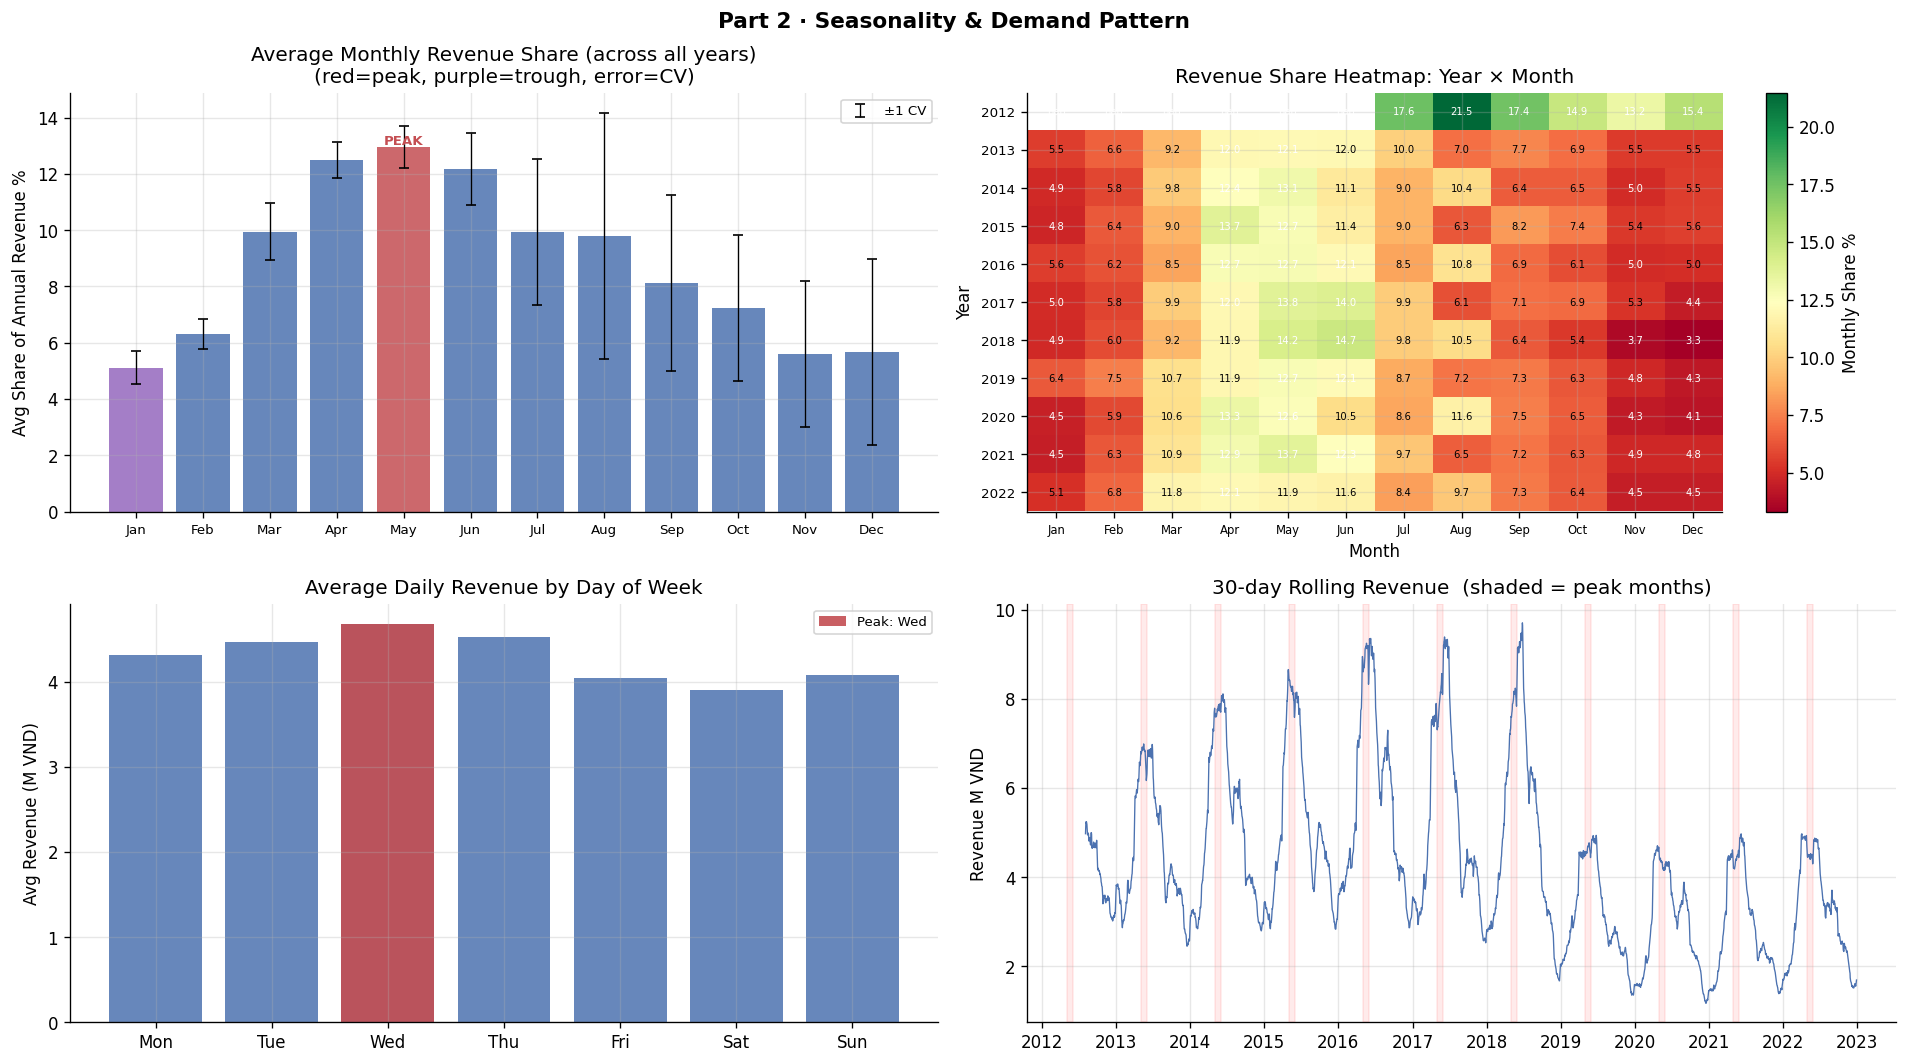

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

# ── A: Seasonal profile bar ──────────────────────────────────────────────────
ax = axes[0]
colors_s = ['#C44E52' if m == peak_month else '#9467BD' if m == trough_month
            else '#4C72B0' for m in seasonal_avg['month']]
bars = ax.bar(seasonal_avg['month'], seasonal_avg['avg_share']*100, color=colors_s, alpha=0.85)
ax.errorbar(seasonal_avg['month'], seasonal_avg['avg_share']*100,
            yerr=seasonal_cv.values*seasonal_avg['avg_share'].values*100,
            fmt='none', color='black', capsize=3, lw=0.8, label='±1 CV')
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_LABELS, fontsize=8)
ax.set_title('Average Monthly Revenue Share (across all years)\n(red=peak, purple=trough, error=CV)')
ax.set_ylabel('Avg Share of Annual Revenue %')
ax.legend(fontsize=8)
ax.text(peak_month, seasonal_avg.loc[seasonal_avg['month']==peak_month,'avg_share'].values[0]*100+0.1,
        'PEAK', ha='center', fontsize=8, color='#C44E52', fontweight='bold')

# ── B: Year × Month heatmap ───────────────────────────────────────────────────
ax = axes[1]
pivot = monthly.pivot(index='year', columns='month', values='share') * 100
import matplotlib.colors as mcolors
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', origin='upper')
ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_LABELS, fontsize=7)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index.astype(int), fontsize=8)
for i in range(len(pivot.index)):
    for j in range(12):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=6,
                color='black' if 5 < val < 12 else 'white')
plt.colorbar(im, ax=ax, label='Monthly Share %')
ax.set_title('Revenue Share Heatmap: Year × Month'); ax.set_xlabel('Month'); ax.set_ylabel('Year')

# ── C: Day-of-week ────────────────────────────────────────────────────────────
ax = axes[2]
ax.bar(range(7), dow_avg.values/1e6, color='#4C72B0', alpha=0.85)
ax.set_xticks(range(7)); ax.set_xticklabels(DOW_LABELS)
ax.set_title('Average Daily Revenue by Day of Week'); ax.set_ylabel('Avg Revenue (M VND)')
peak_dow = dow_avg.idxmax()
ax.bar(peak_dow, dow_avg[peak_dow]/1e6, color='#C44E52', alpha=0.9, label=f'Peak: {DOW_LABELS[peak_dow]}')
ax.legend(fontsize=8)

# ── D: 30-day rolling Revenue ─────────────────────────────────────────────────
ax = axes[3]
daily_roll = sales.set_index('Date')['Revenue'].rolling(30).mean()
ax.plot(daily_roll.index, daily_roll.values/1e6, lw=0.8, color='#4C72B0')
# Shade peak months (Nov-Dec)
for yr in sales['year'].unique():
    for mo in [peak_month]:
        start = pd.Timestamp(yr, mo, 1)
        end   = pd.Timestamp(yr, mo, 28) + pd.offsets.MonthEnd(0)
        ax.axvspan(start, end, alpha=0.08, color='red')
ax.set_title('30-day Rolling Revenue  (shaded = peak months)'); ax.set_ylabel('Revenue M VND')
ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

plt.suptitle('Part 2 · Seasonality & Demand Pattern', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fin_p2_seasonality.png', bbox_inches='tight')
plt.show()


## Part 3 · Promotion Impact
*Stackable promo* = one order contains items from **>1 distinct promo_id**.  
We test whether stackable promos lead to a significantly higher return rate.

In [6]:
import math
from scipy import stats as sp_stats

# ── Promo classification per order ──────────────────────────────────────────
order_promo = items.groupby('order_id').agg(
    total_qty        = ('quantity',        'sum'),
    total_rev        = ('rev_line',        'sum'),
    n_distinct_promos= ('promo_id',        lambda x: x.dropna().nunique()),
    has_promo        = ('promo_id',        lambda x: x.notna().any()),
    total_discount   = ('discount_amount', 'sum'),
).reset_index()

order_promo['promo_type'] = np.where(
    order_promo['n_distinct_promos'] > 1, 'stackable',
    np.where(order_promo['has_promo'], 'single_promo', 'no_promo')
)
order_promo['AOV'] = order_promo['total_rev'] / order_promo['total_qty']
order_promo['discount_depth_pct'] = (
    order_promo['total_discount'] / order_promo['total_rev'] * 100
).clip(0, 100)

returned_orders = set(rets['order_id'].unique())
order_promo['returned'] = order_promo['order_id'].isin(returned_orders)

# ── Key finding: stackable promos ────────────────────────────────────────────
n_stackable   = int((order_promo['promo_type'] == 'stackable').sum())
pct_stackable = n_stackable / len(order_promo) * 100
print(f'Stackable promo orders : {n_stackable:,}  ({pct_stackable:.1f}% of all orders)')
if n_stackable == 0:
    print('>>> FINDING: Promo system does NOT allow stacking — each order has at most')
    print('    one unique promo_id across all its items. Cannot inflate AOV via stacking.')

# ── Summary by promo type ────────────────────────────────────────────────────
promo_summary = order_promo.groupby('promo_type').agg(
    n_orders     = ('order_id',             'count'),
    avg_AOV      = ('AOV',                  'mean'),
    avg_qty      = ('total_qty',            'mean'),
    avg_discount = ('discount_depth_pct',   'mean'),
    return_rate  = ('returned',             'mean'),
).reset_index()
promo_summary['return_rate_pct'] = promo_summary['return_rate'] * 100
promo_types_present = promo_summary['promo_type'].tolist()
promo_summary = promo_summary.sort_values('n_orders', ascending=False)

print()
print('=== Promo Type Summary ===')
print(promo_summary[['promo_type','n_orders','avg_AOV','avg_qty','avg_discount','return_rate_pct']].to_string(index=False))

# ── Statistical test (promo vs no-promo) ──────────────────────────────────────
single_ret  = order_promo[order_promo['promo_type']=='single_promo']['returned']
nopromo_ret = order_promo[order_promo['promo_type']=='no_promo']['returned']

def z_test_proportions(s1, s2, label):
    if len(s1) == 0 or len(s2) == 0:
        print(f'{label}: skipped (empty group)')
        return
    p1, p2 = s1.mean(), s2.mean()
    se = np.sqrt(p1*(1-p1)/len(s1) + p2*(1-p2)/len(s2))
    z  = (p1 - p2) / se if se > 0 else 0
    pval = 2*(1 - sp_stats.norm.cdf(abs(z)))
    sig  = ('*** p<0.001' if pval < 0.001 else '** p<0.01' if pval < 0.01
            else '* p<0.05' if pval < 0.05 else 'n.s.')
    direction = 'higher' if p1 > p2 else 'lower'
    print(f'{label}: rate_diff={p1-p2:+.4f}  z={z:.2f}  {sig}  ({direction})')

print()
print('=== Return Rate Significance Tests ===')
z_test_proportions(single_ret, nopromo_ret, 'Single-promo vs No-promo')

# ── Promo usage by category ───────────────────────────────────────────────────
promo_cat = (
    items_prod.groupby('category')
    .agg(pct_with_promo=('promo_id', lambda x: x.notna().mean()*100),
         avg_discount=('discount_amount', 'mean'))
    .reset_index()
    .sort_values('pct_with_promo', ascending=False)
)
print()
print('=== Promo Usage by Category ===')
print(promo_cat.to_string(index=False))

# ── Discount depth bins ───────────────────────────────────────────────────────
promo_orders = order_promo[order_promo['has_promo']].copy()
promo_orders['disc_bin'] = pd.cut(promo_orders['discount_depth_pct'],
                                   bins=[0, 5, 10, 20, 50, 101],
                                   labels=['0-5%','5-10%','10-20%','20-50%','>50%'])
disc_return = (promo_orders.groupby('disc_bin', observed=True)['returned']
               .agg(['mean','count']).reset_index())
disc_return.columns = ['disc_bin','return_rate','n_orders']
disc_return['return_rate_pct'] = disc_return['return_rate'] * 100
print()
print('=== Return Rate by Discount Depth ===')
print(disc_return.to_string(index=False))

# ── Promo annual coverage ─────────────────────────────────────────────────────
items_with_date = items.merge(orders[['order_id','order_date']], on='order_id', how='left')
items_with_date['year'] = items_with_date['order_date'].dt.year
promo_annual = (items_with_date.groupby('year')
                .agg(pct_promo=('promo_id', lambda x: x.notna().mean()*100)).reset_index())
print()
print('=== Annual Promo Coverage % ===')
print(promo_annual.to_string(index=False))


Stackable promo orders : 0  (0.0% of all orders)
>>> FINDING: Promo system does NOT allow stacking — each order has at most
    one unique promo_id across all its items. Cannot inflate AOV via stacking.

=== Promo Type Summary ===
  promo_type  n_orders     avg_AOV  avg_qty  avg_discount  return_rate_pct
    no_promo    398703 5865.939516 4.940392      0.000000         5.571064
single_promo    248242 4644.814080 5.008798     14.094953         5.579233



=== Return Rate Significance Tests ===
Single-promo vs No-promo: rate_diff=+0.0001  z=0.14  n.s.  (higher)

=== Promo Usage by Category ===
  category  pct_with_promo  avg_discount
   Outdoor       41.671859    544.206062
Streetwear       37.523664   1455.708298
    Casual       33.658455    848.784528
      GenZ       32.918001    400.681388

=== Return Rate by Discount Depth ===
disc_bin  return_rate  n_orders  return_rate_pct
    0-5%     0.056310     20689         5.631012
   5-10%     0.057311     24149         5.731086
  10-20%     0.055585    181038         5.558502
  20-50%     0.055352     22366         5.535187



=== Annual Promo Coverage % ===
 year  pct_promo
 2012   0.000000
 2013  46.403178
 2014  37.288936
 2015  46.454932
 2016  35.075637
 2017  44.440860
 2018  33.607517
 2019  45.061770
 2020  36.666846
 2021  44.754959
 2022  37.207103


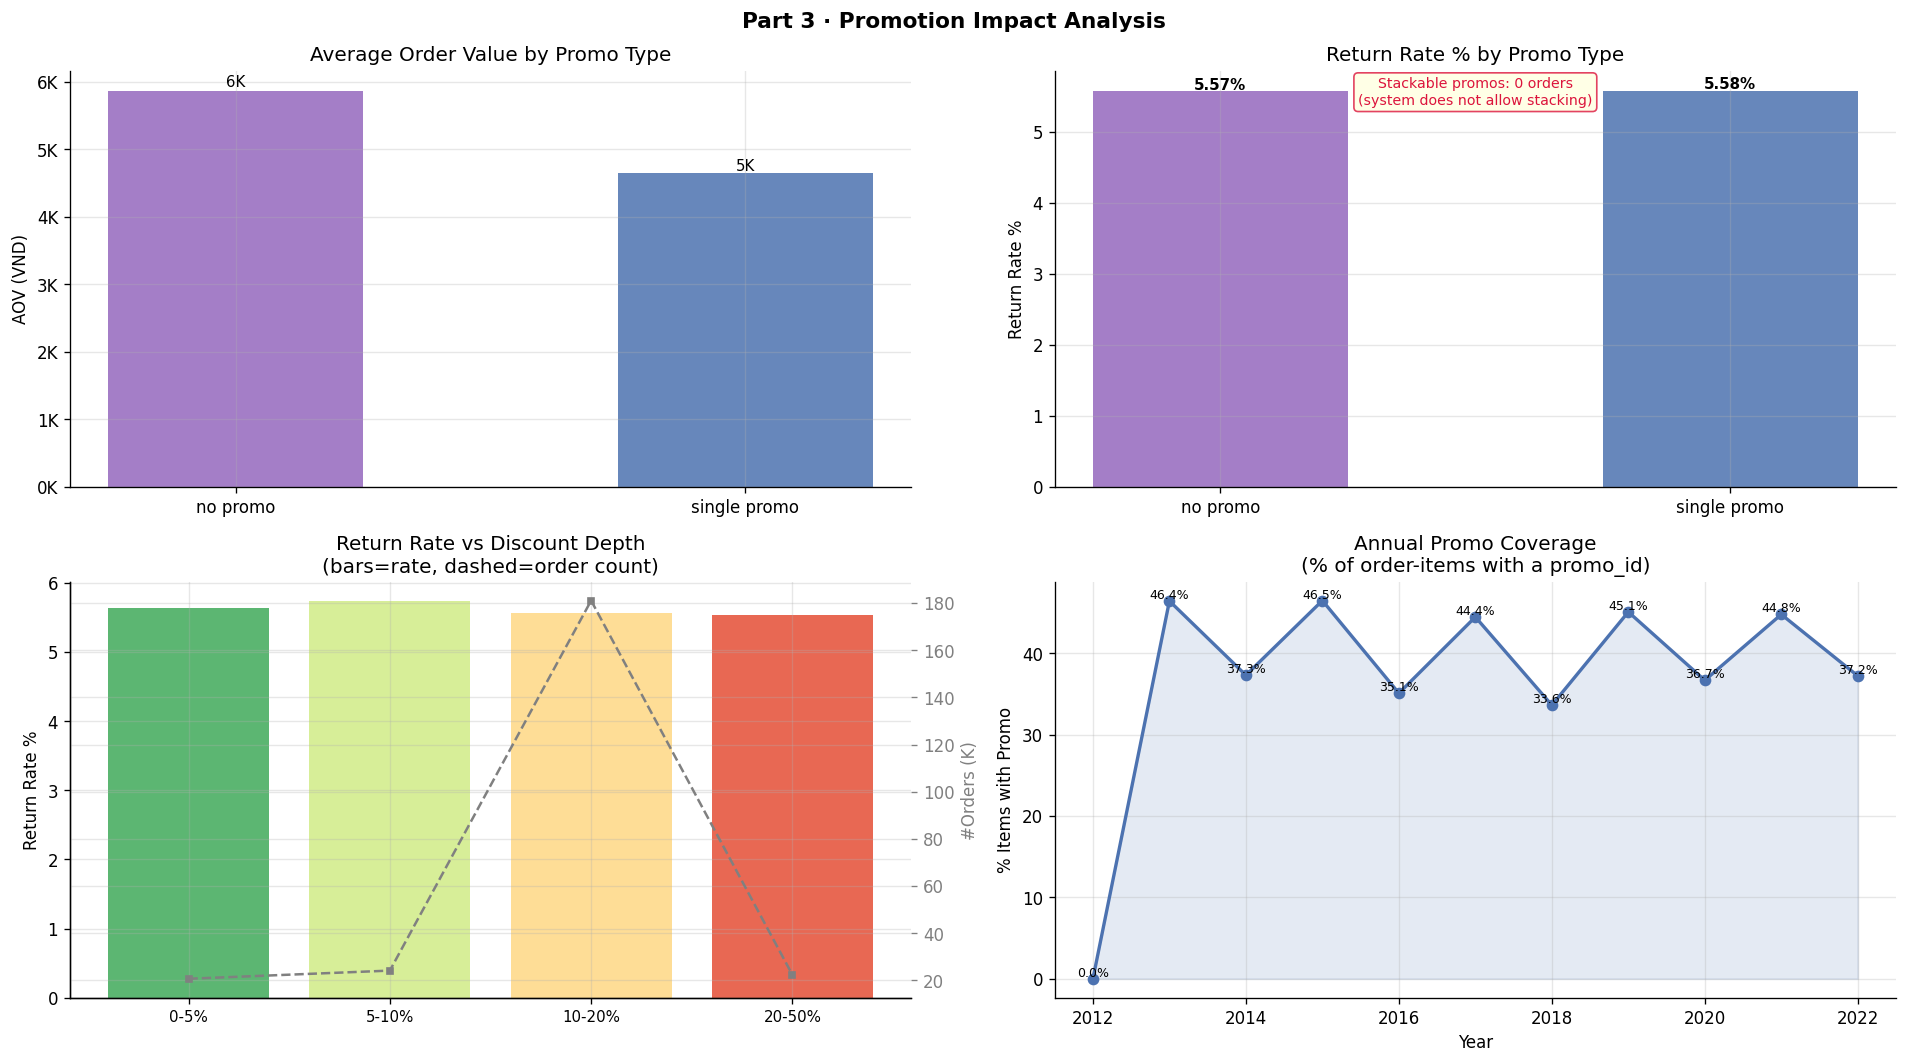

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

PROMO_COLORS = {'no_promo':'#9467BD','single_promo':'#4C72B0','stackable':'#C44E52'}
present_types = [t for t in ['no_promo','single_promo','stackable'] if t in promo_types_present]
ps_plot  = promo_summary.set_index('promo_type').reindex(present_types).dropna().reset_index()
x        = np.arange(len(ps_plot))
colors_  = [PROMO_COLORS[t] for t in ps_plot['promo_type']]

# ── A: AOV by promo type ──────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, ps_plot['avg_AOV'], color=colors_, width=0.5, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([t.replace('_',' ') for t in ps_plot['promo_type']])
ax.set_title('Average Order Value by Promo Type'); ax.set_ylabel('AOV (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e3:.0f}K'))
for bar, val in zip(bars, ps_plot['avg_AOV']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f'{val/1e3:.0f}K', ha='center', fontsize=9)

# ── B: Return rate by promo type ─────────────────────────────────────────────
ax = axes[1]
bars2 = ax.bar(x, ps_plot['return_rate_pct'], color=colors_, width=0.5, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([t.replace('_',' ') for t in ps_plot['promo_type']])
ax.set_title('Return Rate % by Promo Type'); ax.set_ylabel('Return Rate %')
for bar, val in zip(bars2, ps_plot['return_rate_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.03,
            f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')
if n_stackable == 0:
    ax.text(0.5, 0.92, 'Stackable promos: 0 orders\n(system does not allow stacking)',
            transform=ax.transAxes, ha='center', fontsize=8.5, color='crimson',
            bbox=dict(boxstyle='round', fc='lightyellow', ec='crimson', alpha=0.8))

# ── C: Discount depth vs return rate ─────────────────────────────────────────
ax   = axes[2]
disc_colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(disc_return)))
ax.bar(range(len(disc_return)), disc_return['return_rate_pct'], color=disc_colors, alpha=0.85)
ax.set_xticks(range(len(disc_return)))
ax.set_xticklabels(disc_return['disc_bin'].astype(str), fontsize=9)
ax2c = ax.twinx()
ax2c.plot(range(len(disc_return)), disc_return['n_orders']/1e3, color='grey',
          marker='s', ms=4, lw=1.5, linestyle='--')
ax2c.set_ylabel('#Orders (K)', color='grey'); ax2c.tick_params(axis='y', colors='grey')
ax.set_title('Return Rate vs Discount Depth\n(bars=rate, dashed=order count)')
ax.set_ylabel('Return Rate %')

# ── D: Annual promo coverage trend ───────────────────────────────────────────
ax  = axes[3]
ax.plot(promo_annual['year'], promo_annual['pct_promo'], marker='o', lw=2, color='#4C72B0')
ax.fill_between(promo_annual['year'], promo_annual['pct_promo'], alpha=0.15, color='#4C72B0')
ax.set_title('Annual Promo Coverage\n(% of order-items with a promo_id)')
ax.set_xlabel('Year'); ax.set_ylabel('% Items with Promo')
for _, row in promo_annual.iterrows():
    ax.text(row['year'], row['pct_promo']+0.3, f'{row["pct_promo"]:.1f}%', ha='center', fontsize=7.5)

plt.suptitle('Part 3 · Promotion Impact Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fin_p3_promo.png', bbox_inches='tight')
plt.show()


## Part 4 · Product Portfolio — Pareto 80/20

In [8]:
# Revenue by product
prod_rev = (
    items_prod.groupby(['product_id','category','segment'])
    .agg(revenue=('rev_line','sum'), qty=('quantity','sum'), n_orders=('order_id','nunique'))
    .reset_index()
    .sort_values('revenue', ascending=False)
    .reset_index(drop=True)
)
total_rev = prod_rev['revenue'].sum()
prod_rev['cum_rev']     = prod_rev['revenue'].cumsum()
prod_rev['cum_pct']     = prod_rev['cum_rev'] / total_rev * 100
prod_rev['sku_rank_pct'] = (prod_rev.index + 1) / len(prod_rev) * 100

# Thresholds
idx_80 = (prod_rev['cum_pct'] <= 80).sum()
idx_50 = (prod_rev['cum_pct'] <= 50).sum()

pct_sku_for_80 = idx_80 / len(prod_rev) * 100
pct_sku_for_50 = idx_50 / len(prod_rev) * 100

print(f'Total SKUs with revenue data : {len(prod_rev):,}')
print(f'SKUs driving 50% of revenue  : {idx_50:,}  ({pct_sku_for_50:.1f}% of SKUs)')
print(f'SKUs driving 80% of revenue  : {idx_80:,}  ({pct_sku_for_80:.1f}% of SKUs)')
print(f'Top 10 SKUs revenue share    : {prod_rev.head(10)["revenue"].sum()/total_rev*100:.1f}%')
print()

# Category Pareto
cat_rev = (
    items_prod.groupby('category')['rev_line'].sum()
    .sort_values(ascending=False).reset_index()
)
cat_rev.columns = ['category','revenue']
cat_rev['cum_pct'] = cat_rev['revenue'].cumsum() / cat_rev['revenue'].sum() * 100
print('=== Category Revenue Share ===')
print(cat_rev.to_string(index=False))

# Long tail: bottom 50% of SKUs
bottom_50_pct = prod_rev[prod_rev['sku_rank_pct'] > 50]['revenue'].sum() / total_rev * 100
print(f'\nBottom 50% of SKUs → only {bottom_50_pct:.1f}% of revenue (long tail)')


Total SKUs with revenue data : 1,598
SKUs driving 50% of revenue  : 80  (5.0% of SKUs)
SKUs driving 80% of revenue  : 294  (18.4% of SKUs)
Top 10 SKUs revenue share    : 15.6%

=== Category Revenue Share ===
  category      revenue    cum_pct
Streetwear 1.313135e+10  79.920666
   Outdoor 2.494883e+09  95.105148
    Casual 4.606484e+08  97.908770
      GenZ 3.435991e+08 100.000000

Bottom 50% of SKUs → only 3.0% of revenue (long tail)


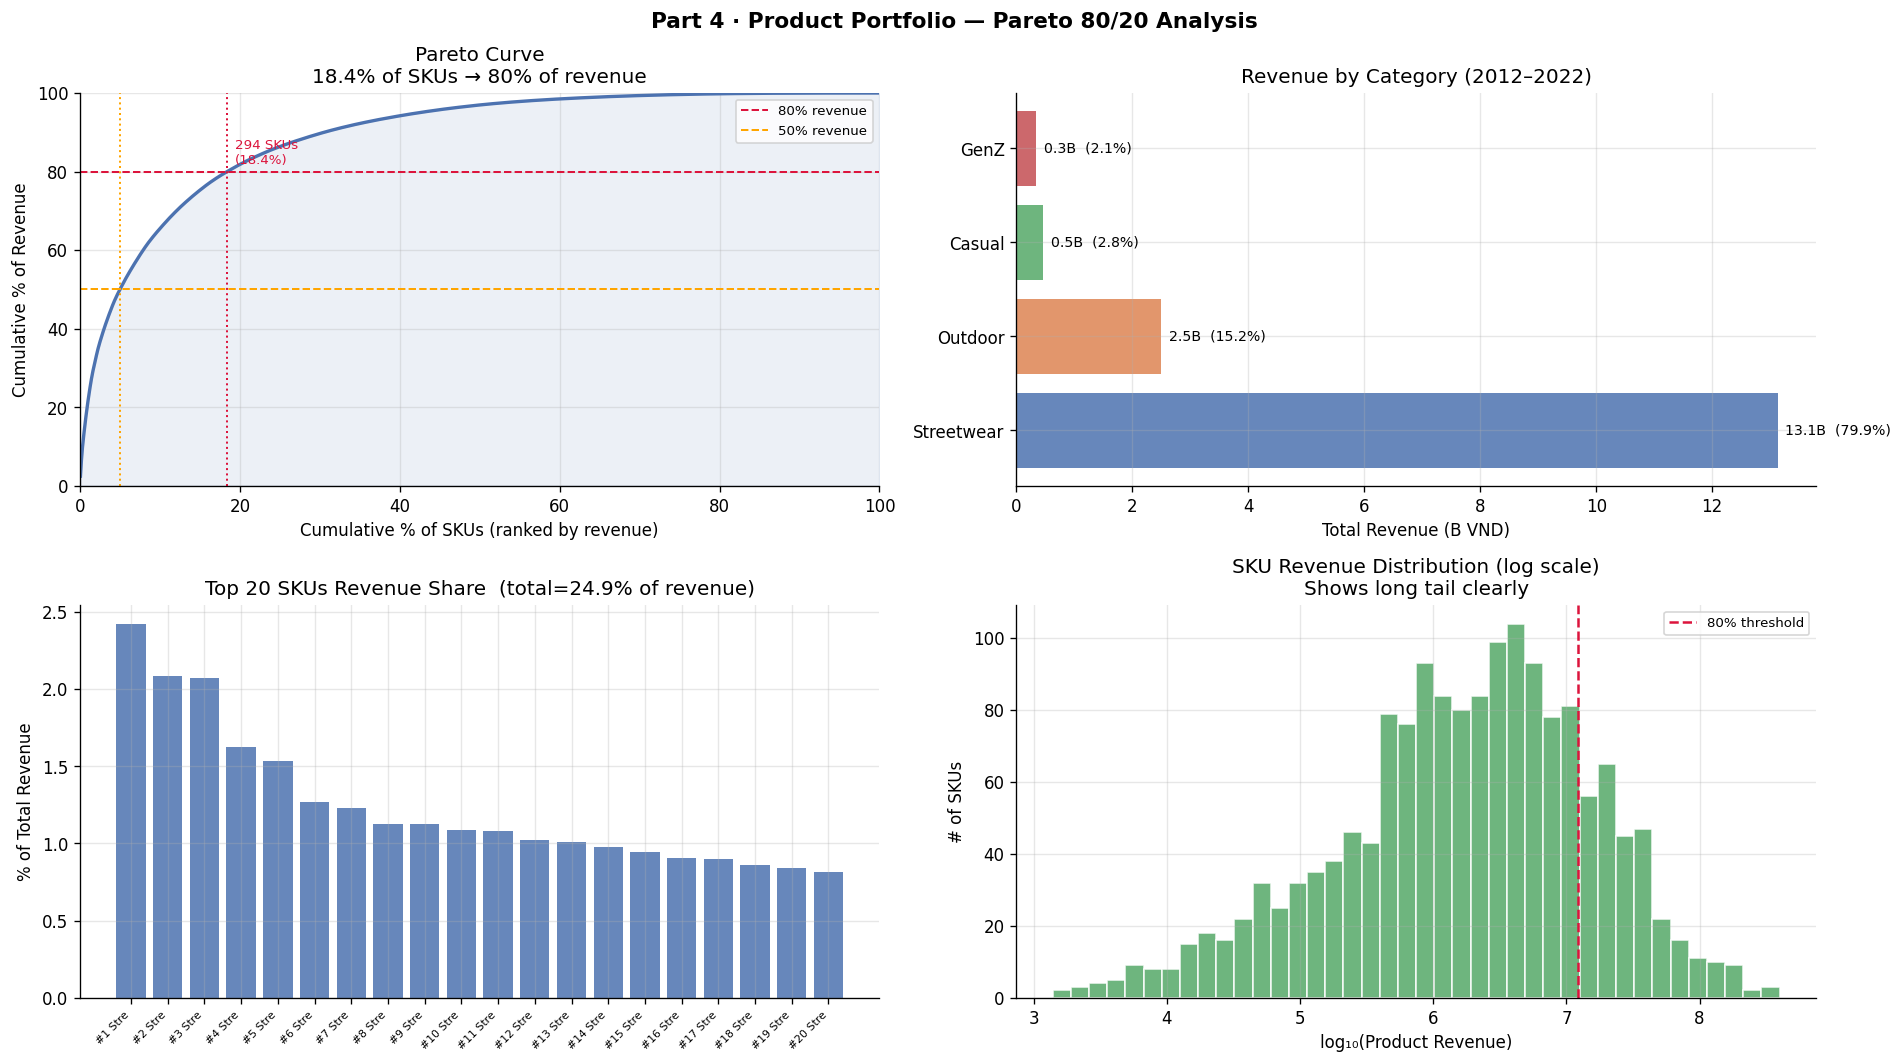

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

# ── A: Pareto curve ───────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(prod_rev['sku_rank_pct'], prod_rev['cum_pct'], color='#4C72B0', lw=2)
ax.axhline(80, color='crimson', lw=1.2, linestyle='--', label='80% revenue')
ax.axhline(50, color='orange',  lw=1.2, linestyle='--', label='50% revenue')
ax.axvline(pct_sku_for_80, color='crimson', lw=1.2, linestyle=':')
ax.axvline(pct_sku_for_50, color='orange',  lw=1.2, linestyle=':')
ax.fill_between(prod_rev['sku_rank_pct'], prod_rev['cum_pct'], alpha=0.1, color='#4C72B0')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel('Cumulative % of SKUs (ranked by revenue)'); ax.set_ylabel('Cumulative % of Revenue')
ax.set_title(f'Pareto Curve\n{pct_sku_for_80:.1f}% of SKUs → 80% of revenue')
ax.text(pct_sku_for_80+1, 82, f'{idx_80} SKUs\n({pct_sku_for_80:.1f}%)',
        fontsize=8, color='crimson')
ax.legend(fontsize=8)

# ── B: Revenue by category (horizontal bar) ───────────────────────────────────
ax = axes[1]
cat_colors = ['#4C72B0','#DD8452','#55A868','#C44E52'][:len(cat_rev)]
bars = ax.barh(cat_rev['category'], cat_rev['revenue']/1e9, color=cat_colors, alpha=0.85)
ax.set_xlabel('Total Revenue (B VND)'); ax.set_title('Revenue by Category (2012–2022)')
for bar, val, pct in zip(bars, cat_rev['revenue'], cat_rev['cum_pct']):
    ax.text(val/1e9 + cat_rev['revenue'].max()/1e9*0.01, bar.get_y()+bar.get_height()/2,
            f'{val/1e9:.1f}B  ({val/cat_rev["revenue"].sum()*100:.1f}%)',
            va='center', fontsize=8.5)

# ── C: Top 20 SKUs revenue distribution ──────────────────────────────────────
ax = axes[2]
top20 = prod_rev.head(20).copy()
top20_labels = [f"#{i+1} {r['category'][:4]}" for i, r in top20.iterrows()]
ax.bar(range(20), top20['revenue']/total_rev*100, color='#4C72B0', alpha=0.85)
ax.set_xticks(range(20)); ax.set_xticklabels(top20_labels, fontsize=6.5, rotation=45, ha='right')
share_top20 = top20['revenue'].sum()/total_rev*100
ax.set_title(f'Top 20 SKUs Revenue Share  (total={share_top20:.1f}% of revenue)')
ax.set_ylabel('% of Total Revenue')

# ── D: Revenue distribution histogram (log scale) ────────────────────────────
ax = axes[3]
rev_vals = prod_rev['revenue']
ax.hist(np.log10(rev_vals.clip(1)), bins=40, color='#55A868', alpha=0.85, edgecolor='white')
ax.axvline(np.log10(prod_rev.iloc[idx_80-1]['revenue']), color='crimson', lw=1.5,
           linestyle='--', label=f'80% threshold')
ax.set_xlabel('log₁₀(Product Revenue)'); ax.set_ylabel('# of SKUs')
ax.set_title('SKU Revenue Distribution (log scale)\nShows long tail clearly')
ax.legend(fontsize=8)

plt.suptitle('Part 4 · Product Portfolio — Pareto 80/20 Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fin_p4_pareto.png', bbox_inches='tight')
plt.show()


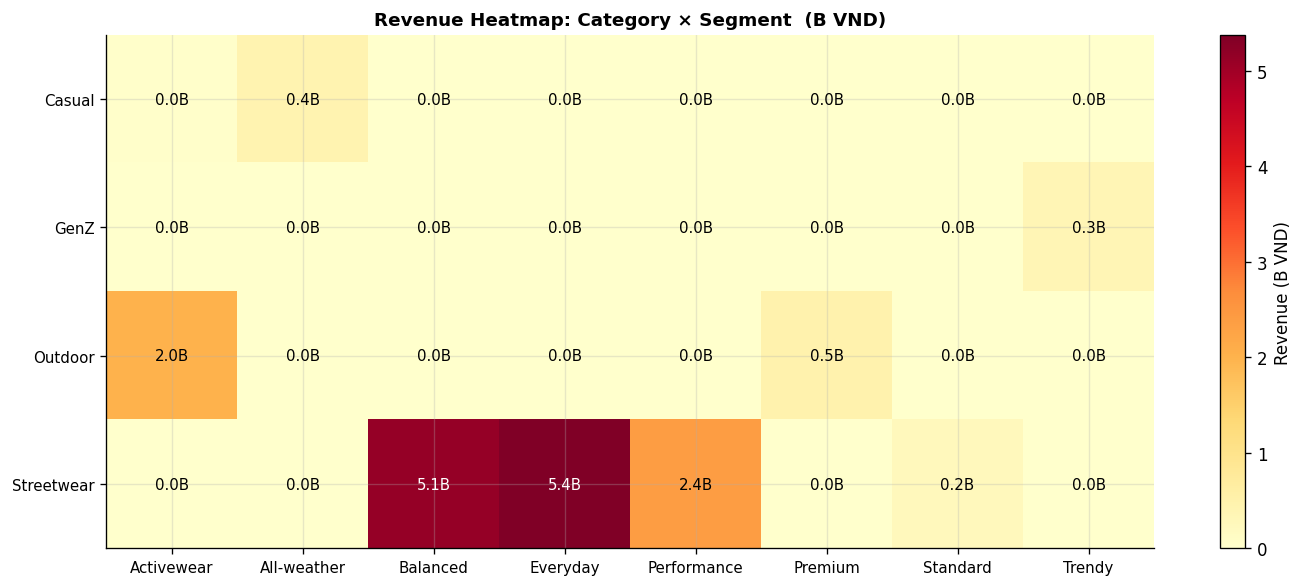

In [10]:
# Category × Segment revenue heatmap
cat_seg = (
    items_prod.groupby(['category','segment'])['rev_line'].sum()
    .unstack(fill_value=0) / 1e9
)
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(cat_seg.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(cat_seg.columns))); ax.set_xticklabels(cat_seg.columns, fontsize=9)
ax.set_yticks(range(len(cat_seg.index)));   ax.set_yticklabels(cat_seg.index,   fontsize=9)
for i in range(len(cat_seg.index)):
    for j in range(len(cat_seg.columns)):
        val = cat_seg.values[i, j]
        ax.text(j, i, f'{val:.1f}B', ha='center', va='center',
                fontsize=9, color='black' if val < cat_seg.values.max()*0.6 else 'white')
plt.colorbar(im, ax=ax, label='Revenue (B VND)')
ax.set_title('Revenue Heatmap: Category × Segment  (B VND)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fin_p4_heatmap.png', bbox_inches='tight')
plt.show()


## Summary

In [11]:
print('=' * 60)
print('FINANCIAL PERFORMANCE SUMMARY')
print('=' * 60)
print()
print('=== Part 1: Revenue & Gross Profit ===')
print(f'  Peak revenue year : {annual.loc[annual["Revenue"].idxmax(), "year"]}')
print(f'  Peak GM% year     : {annual.loc[annual["GM_pct"].idxmax(), "year"]} ({annual["GM_pct"].max():.1f}%)')
print(f'  Worst GM% year    : {annual.loc[annual["GM_pct"].idxmin(), "year"]} ({annual["GM_pct"].min():.1f}%)')
anomaly_years = anomalies["year"].tolist()
print(f'  ⚠ Anomalous low-GM years: {anomaly_years if anomaly_years else "None detected"}')
print()
print('=== Part 2: Seasonality ===')
print(f'  Peak month  : {MONTH_LABELS[peak_month-1]}  (avg {seasonal_avg["avg_share"].max()*100:.2f}% of annual rev)')
print(f'  Trough month: {MONTH_LABELS[trough_month-1]}  (avg {seasonal_avg["avg_share"].min()*100:.2f}% of annual rev)')
print(f'  Peak/Trough ratio: {seasonal_avg["avg_share"].max()/seasonal_avg["avg_share"].min():.2f}x')
print()
print('=== Part 3: Promotion Impact ===')
for _, row in promo_summary.iterrows():
    print(f'  {row["promo_type"]:14s}: {row["n_orders"]:>8,} orders  return_rate={row["return_rate_pct"]:.2f}%  AOV={row["avg_AOV"]/1e3:.0f}K')
if n_stackable == 0:
    print('  >>> Stackable promos: 0 — system enforces single-promo-per-order')
else:
    print(f'  ⚠ Stackable orders: {n_stackable:,} ({pct_stackable:.1f}% of all orders)')
print()
print('=== Part 4: Product Pareto ===')
print(f'  Top {idx_80} SKUs ({pct_sku_for_80:.1f}% of catalog) → 80% of revenue')
print(f'  Top {idx_50} SKUs ({pct_sku_for_50:.1f}% of catalog) → 50% of revenue')
print(f'  Bottom 50% of SKUs → only {bottom_50_pct:.1f}% of revenue')
print()
print('Done.')


FINANCIAL PERFORMANCE SUMMARY

=== Part 1: Revenue & Gross Profit ===
  Peak revenue year : 2016
  Peak GM% year     : 2012 (20.8%)
  Worst GM% year    : 2021 (9.8%)
  ⚠ Anomalous low-GM years: None detected

=== Part 2: Seasonality ===
  Peak month  : May  (avg 12.95% of annual rev)
  Trough month: Jan  (avg 5.11% of annual rev)
  Peak/Trough ratio: 2.53x

=== Part 3: Promotion Impact ===
  no_promo      :  398,703 orders  return_rate=5.57%  AOV=6K
  single_promo  :  248,242 orders  return_rate=5.58%  AOV=5K
  >>> Stackable promos: 0 — system enforces single-promo-per-order

=== Part 4: Product Pareto ===
  Top 294 SKUs (18.4% of catalog) → 80% of revenue
  Top 80 SKUs (5.0% of catalog) → 50% of revenue
  Bottom 50% of SKUs → only 3.0% of revenue

Done.
